# check Langleys

In [1]:
import atmPy.radiation.retrievals.langley_calibration as atmlc
import atmPy.radiation.retrievals.spectral_irradiance as atmspec
import atmPy.aerosols.physics.column_optical_properties as atmcop
import helpers

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
reload(atmspec)
reload(atmspec.atmlangcalib)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [4]:
prefix = '/Users/htelg'
version = '0.6' #this is wehere the langleys go
version_in = '0.2'
serialno = 649
"""
changes
-------
0.6
- with pwv cal retrieval
0.5 
- improved cosine-correction
0.4
- improved airmass
- improved coordinates and included altitude
0.3
- use cloud screening for cleaning
- removed 940 nm channel in langley cleaning!
0.2
- langleys out to 5 atm
"""
p2fld_lang = f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}'
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'
p2fld_lang, fnlut

('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6',
 '/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_649.nc')

# 940 lut

In [5]:
ds_lut = xr.open_dataset(fnlut)
ds_lut = ds_lut.rename({'air_mass': 'airmass'})
ds_lut.attrs.update({'path2file': fnlut})

# create Langles

In [6]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspir

In [7]:
lt = None#lt_pre_648 #None
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025')

In [8]:
p2flist = list(p2fld.glob('*'))
p2flist.sort()

In [9]:
p2flist

[PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250925.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250926.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250927.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250928.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250929.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250930.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20251001.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.cal/v0.2/2025/dav_mfrsr_cosinecorrected_2025100

In [10]:
'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

### 20251018

In [11]:
%matplotlib inline

In [12]:
date = '1018'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'


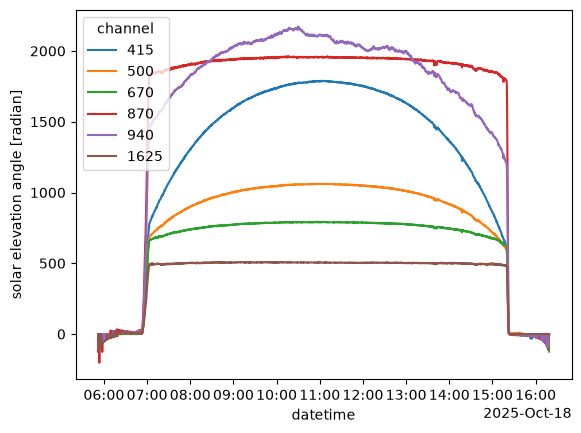

In [13]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [14]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [15]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1210	 skewscale:2.4840
skewness: -0.0559	 skewscale:2.2234
skewness: 0.0891	 skewscale:2.3566
skewness: 0.1715	 skewscale:2.6859
skewness: 0.1879	 skewscale:2.7518
skewness: 0.1453	 skewscale:2.5811
skewness: 0.0704	 skewscale:2.2818
skewness: 0.0202	 skewscale:2.0808
skewness: 0.0170	 skewscale:2.0680
skewness: 0.0165	 skewscale:2.0659
skewness: 0.0105	 skewscale:2.0419
skewness: -0.0122	 skewscale:2.0488
skewness: 0.0011	 skewscale:2.0042
skewness: 0.0222	 skewscale:2.0888
skewness: -0.0378	 skewscale:2.1512
skewness: -0.0125	 skewscale:2.0500
skewness: -0.0041	 skewscale:2.0162
skewness: -0.0334	 skewscale:2.1336
skewness: -0.0404	 skewscale:2.1615
skewness: -0.0562	 skewscale:2.2246


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

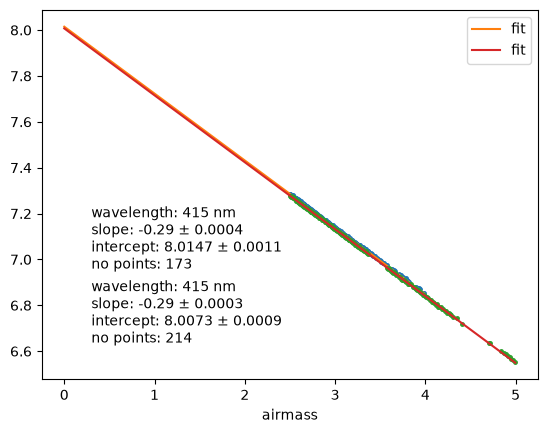

In [16]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

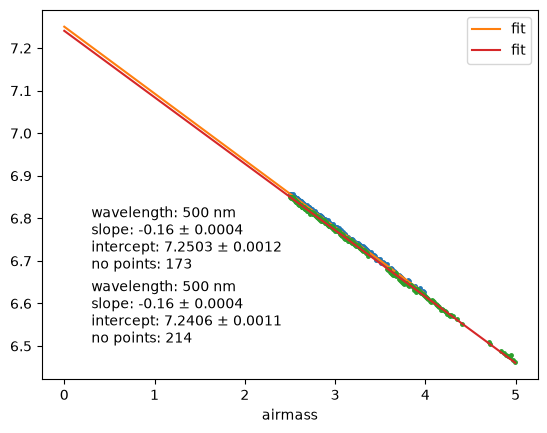

In [17]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

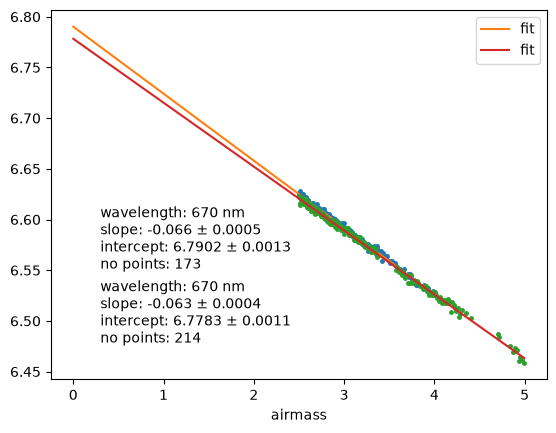

In [18]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

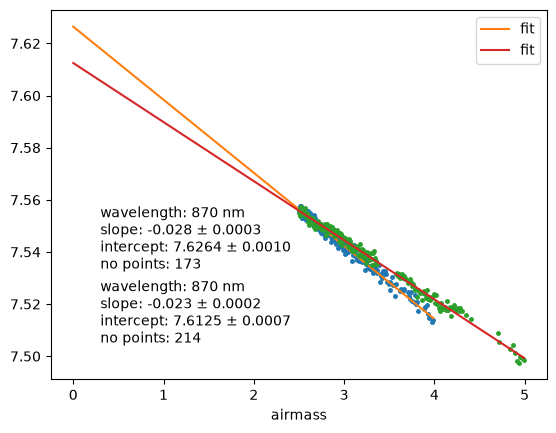

In [19]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

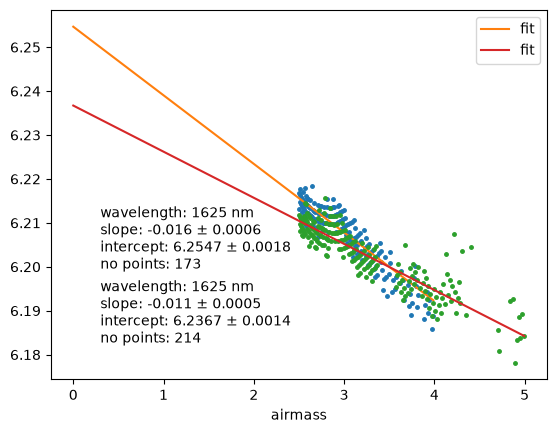

In [20]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [21]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251018.nc')

In [22]:
# p2out.unlink()

In [23]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251018.nc')

In [24]:
# p2out.unlink()

#### pwv

In [25]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

In [26]:
threshold = 3
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0092	 skewscale:3.0826
skewness: -0.0861	 skewscale:3.7750
skewness: -0.0610	 skewscale:3.5491
skewness: -0.1427	 skewscale:4.2845
skewness: 0.0568	 skewscale:3.5108


(1265.0140666750096, 2100.0)

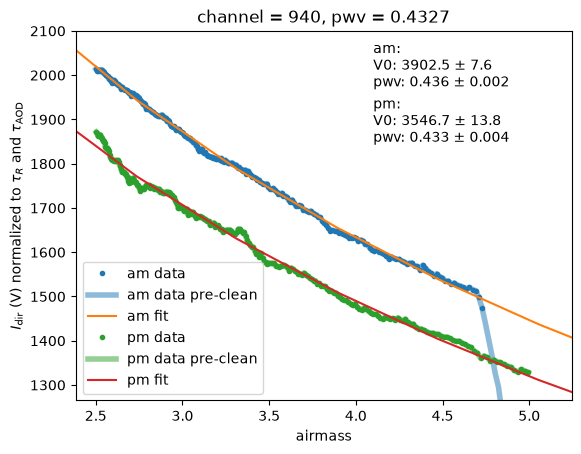

In [28]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 2100)

In [29]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251018.nc')

In [30]:
# p2out.unlink()

In [31]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251018.nc')

In [32]:
# p2out.unlink()

### 20251017

In [33]:
%matplotlib inline

In [34]:
date = '1017'
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

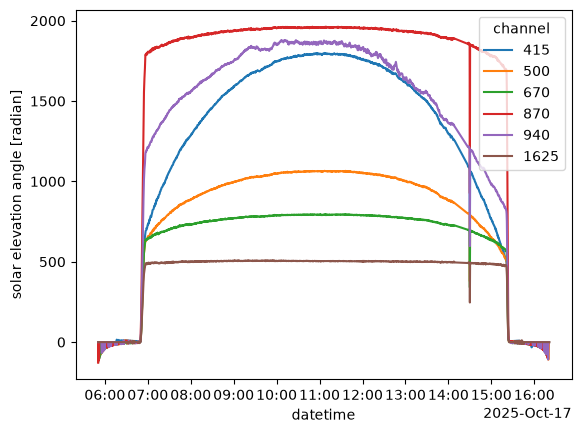

In [35]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [36]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [37]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.0471	 skewscale:2.1884
skewness: -0.0491	 skewscale:2.1964
skewness: -0.0417	 skewscale:2.1670
skewness: -0.0137	 skewscale:2.0548
skewness: 0.0052	 skewscale:2.0208
skewness: 0.0094	 skewscale:2.0376
skewness: 0.0059	 skewscale:2.0236
skewness: -0.0077	 skewscale:2.0307
skewness: -0.0515	 skewscale:2.2060
skewness: 0.0279	 skewscale:2.1117
skewness: 0.0519	 skewscale:2.2075
skewness: 0.0507	 skewscale:2.2027
skewness: 0.0267	 skewscale:2.1070
skewness: 0.0082	 skewscale:2.0329
skewness: 0.0291	 skewscale:2.1165
skewness: 0.0463	 skewscale:2.1853


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

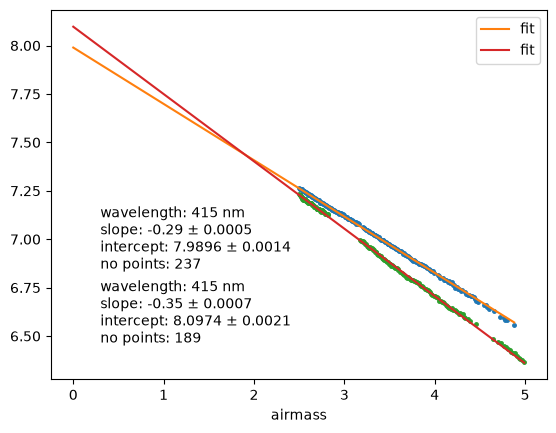

In [38]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

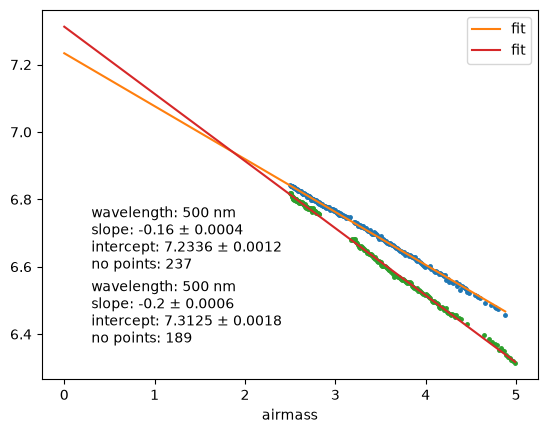

In [39]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

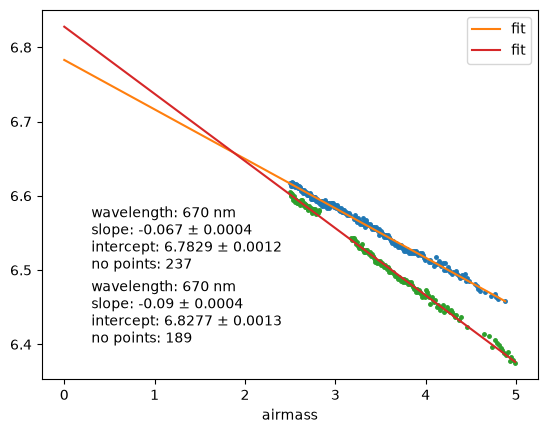

In [40]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

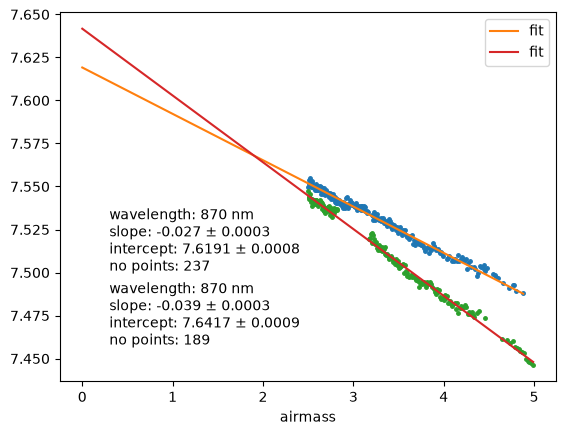

In [41]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

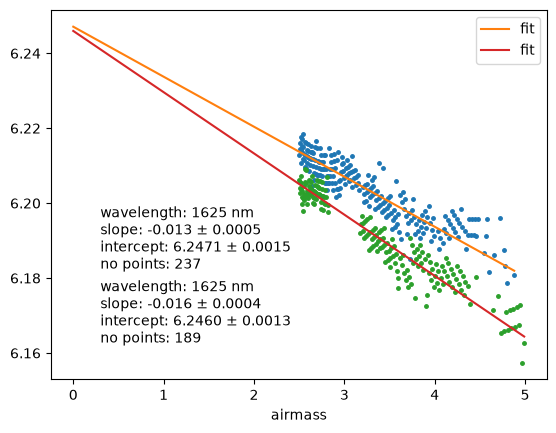

In [42]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [43]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251017.nc')

In [44]:
# p2out.unlink()

In [45]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251017.nc')

In [46]:
# p2out.unlink()

#### pwv

In [47]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

In [48]:
threshold = 3
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: 0.0910	 skewscale:3.8194
skewness: -0.0287	 skewscale:3.2586
skewness: 0.1210	 skewscale:4.0887


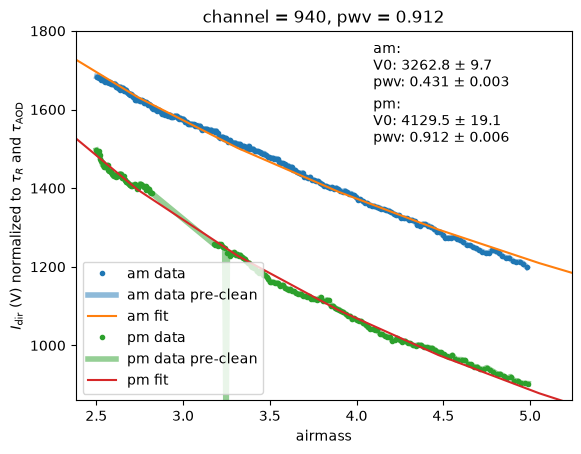

In [51]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1800)
a.legend(loc = 3)

In [52]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251017.nc')

In [53]:
# p2out.unlink()

In [54]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251017.nc')

In [55]:
# p2out.unlink()

### 20251016

In [56]:
%matplotlib inline

In [57]:
date = '1016'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

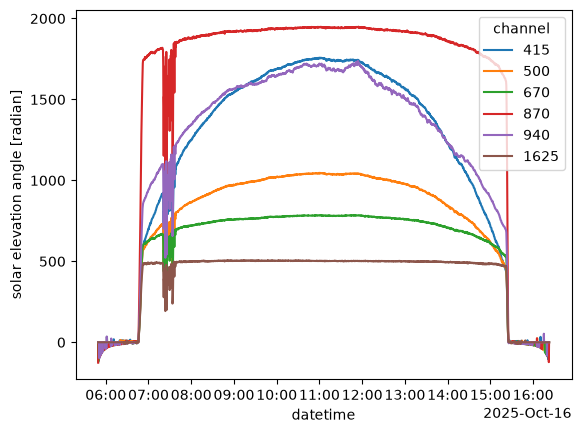

In [58]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [59]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [60]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1161	 skewscale:2.4644
skewness: -0.1452	 skewscale:2.5807
skewness: -0.1963	 skewscale:2.7850
skewness: -0.1874	 skewscale:2.7494
skewness: -0.1593	 skewscale:2.6374
skewness: -0.0749	 skewscale:2.2996
skewness: -0.0068	 skewscale:2.0271
skewness: 0.0665	 skewscale:2.2661
skewness: 0.0736	 skewscale:2.2945
skewness: -0.0891	 skewscale:2.3566
skewness: -0.0072	 skewscale:2.0288
skewness: 0.0397	 skewscale:2.1588
skewness: 0.0443	 skewscale:2.1773


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

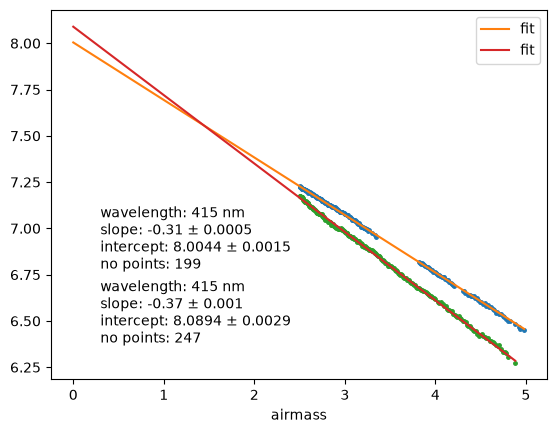

In [61]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

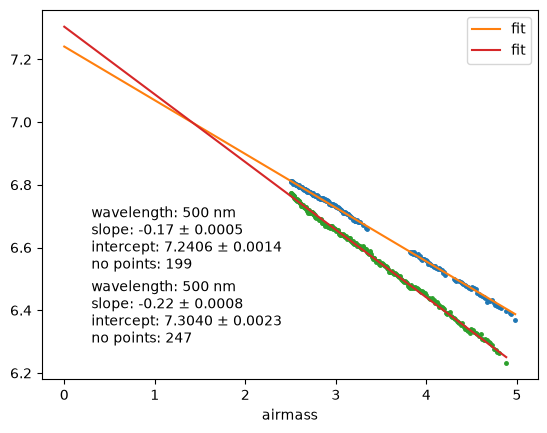

In [62]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

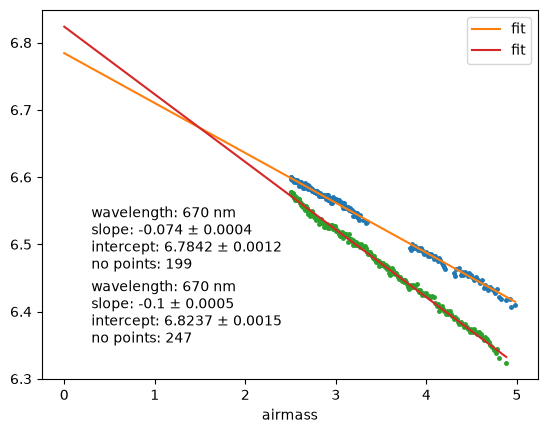

In [63]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

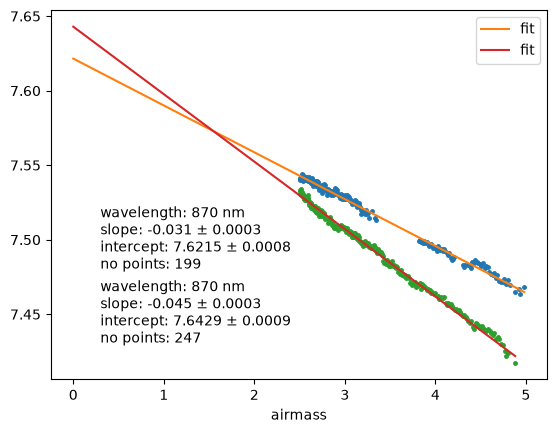

In [64]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

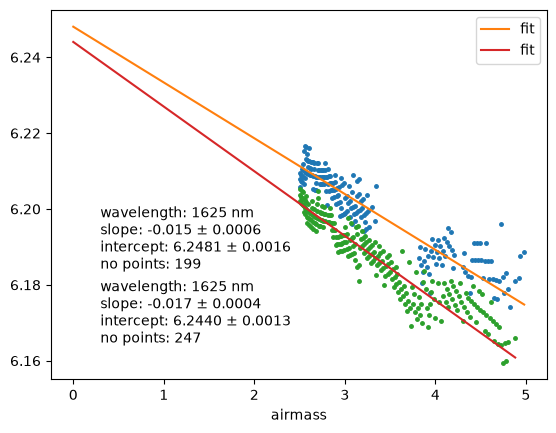

In [65]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [66]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251016.nc')

In [67]:
# p2out.unlink()

In [68]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251016.nc')

In [69]:
# p2out.unlink()

#### pwv

In [70]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.2746	 skewscale:3.0983
skewness: -0.2854	 skewscale:3.1416
skewness: -0.2740	 skewscale:3.0961
skewness: -0.2142	 skewscale:2.8567
skewness: -0.1457	 skewscale:2.5830
skewness: -0.0674	 skewscale:2.2696
skewness: -0.0038	 skewscale:2.0152
skewness: 0.0169	 skewscale:2.0677


skewness: 0.0345	 skewscale:2.1379
skewness: 0.0351	 skewscale:2.1404
skewness: 0.0773	 skewscale:2.3090
skewness: 0.0925	 skewscale:2.3700
skewness: 0.0879	 skewscale:2.3515


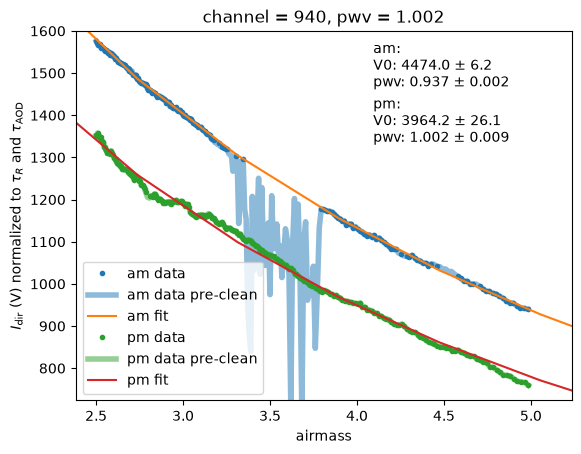

In [71]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)
a.legend(loc = 3)

In [72]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251016.nc')

In [73]:
# p2out.unlink()

In [74]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251016.nc')

In [75]:
# p2out.unlink()

### 20251015

In [76]:
%matplotlib inline

In [77]:
date = '1015'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

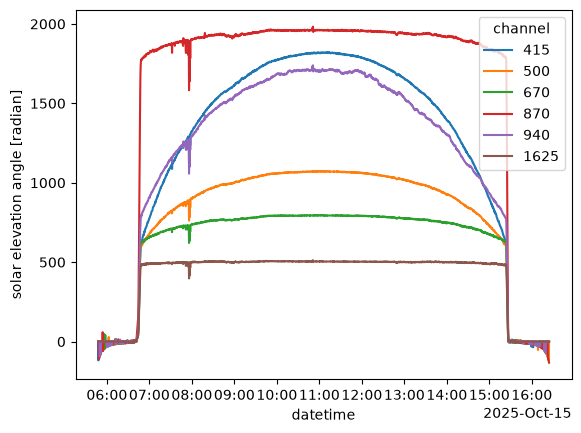

In [78]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [79]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [80]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1701	 skewscale:2.6806
skewness: -0.1665	 skewscale:2.6658
skewness: -0.0790	 skewscale:2.3160
skewness: -0.0490	 skewscale:2.1959
skewness: -0.0083	 skewscale:2.0333
skewness: 0.0048	 skewscale:2.0192
skewness: -0.0534	 skewscale:2.2135
skewness: -0.0632	 skewscale:2.2529
skewness: 0.0903	 skewscale:2.3610
skewness: 0.0697	 skewscale:2.2790
skewness: 0.0760	 skewscale:2.3038
skewness: 0.0643	 skewscale:2.2571
skewness: 0.0413	 skewscale:2.1651
skewness: 0.0412	 skewscale:2.1646
skewness: 0.0435	 skewscale:2.1739


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

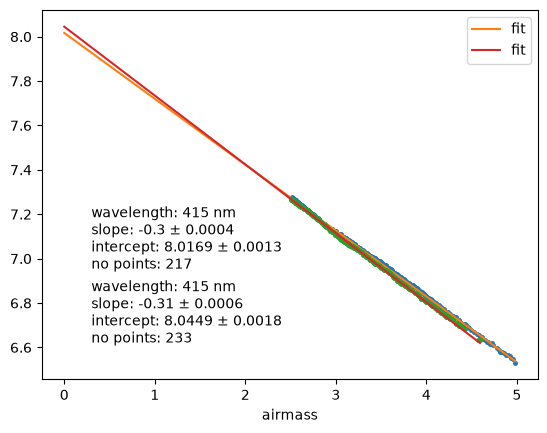

In [81]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

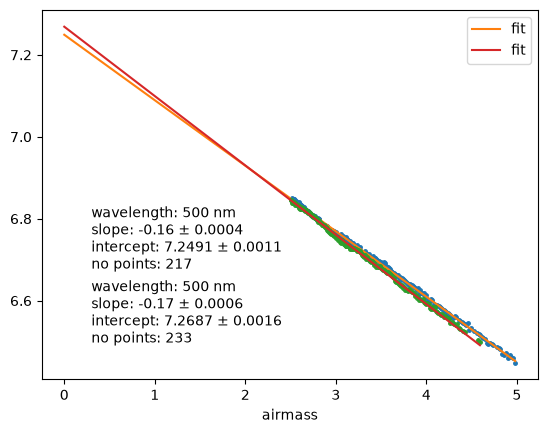

In [82]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

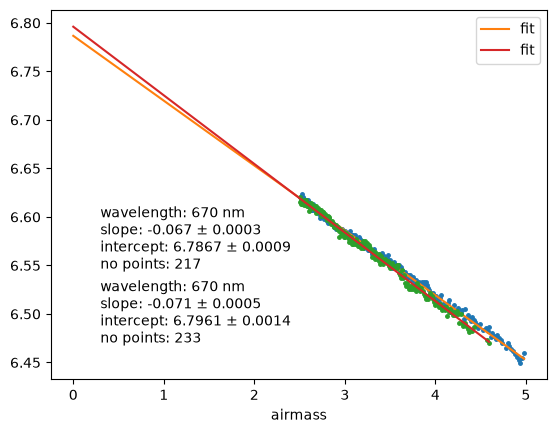

In [83]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

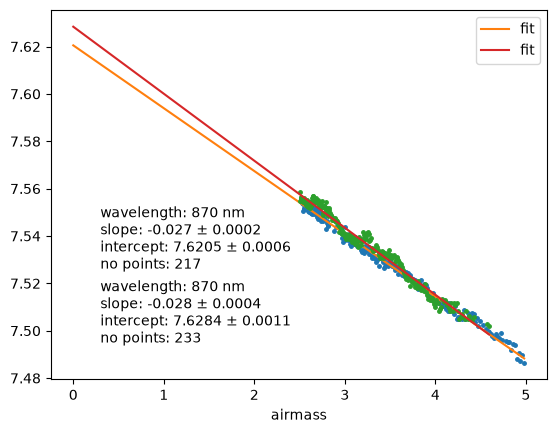

In [84]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

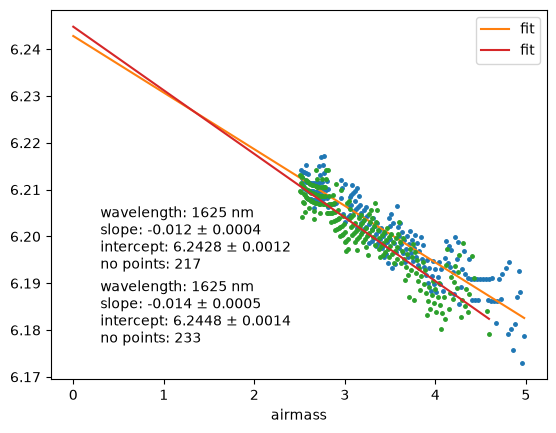

In [85]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [86]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251015.nc')

In [87]:
# p2out.unlink()

In [88]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251015.nc')

In [89]:
# p2out.unlink()

#### pwv

In [90]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.1513	 skewscale:2.6050
skewness: -0.1708	 skewscale:2.6832
skewness: -0.1295	 skewscale:2.5178
skewness: -0.1349	 skewscale:2.5396
skewness: -0.1378	 skewscale:2.5512
skewness: 0.1329	 skewscale:2.5314


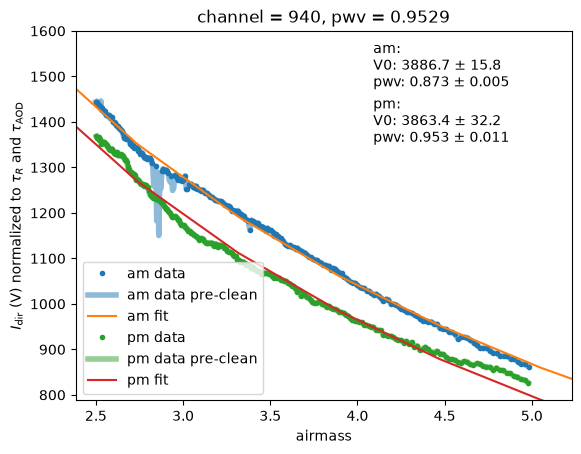

In [91]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)
a.legend(loc = 3)

In [92]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251015.nc')

In [93]:
# p2out.unlink()

In [94]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251015.nc')

In [95]:
# p2out.unlink()

### 20251014

In [96]:
%matplotlib inline

In [97]:
date = '1014'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

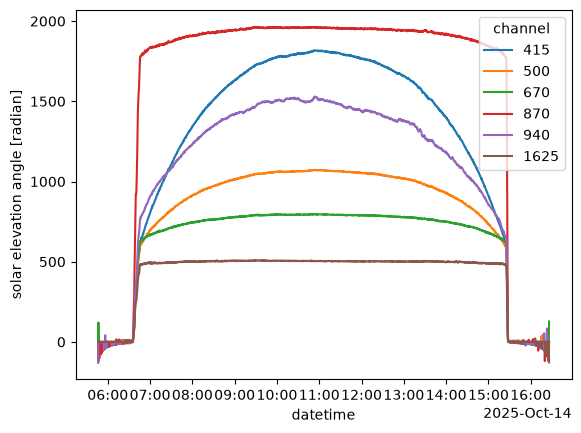

In [98]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [99]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [100]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.1279	 skewscale:2.5115
skewness: 0.1355	 skewscale:2.5420
skewness: 0.1503	 skewscale:2.6013
skewness: 0.1179	 skewscale:2.4717
skewness: 0.0837	 skewscale:2.3348
skewness: 0.1280	 skewscale:2.5120
skewness: 0.0620	 skewscale:2.2478
skewness: 0.0505	 skewscale:2.2021
skewness: 0.0280	 skewscale:2.1119
skewness: 0.0407	 skewscale:2.1629
skewness: 0.0193	 skewscale:2.0774
skewness: 0.0329	 skewscale:2.1317
skewness: 0.0273	 skewscale:2.1092
skewness: 0.0416	 skewscale:2.1664
skewness: 0.0588	 skewscale:2.2352
skewness: 0.0580	 skewscale:2.2321
skewness: 0.0155	 skewscale:2.0620
skewness: 0.0041	 skewscale:2.0164
skewness: -0.0097	 skewscale:2.0389
skewness: -0.0060	 skewscale:2.0239
skewness: 0.0130	 skewscale:2.0520
skewness: -0.0077	 skewscale:2.0307
skewness: -0.0128	 skewscale:2.0514
skewness: -0.0269	 skewscale:2.1074


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

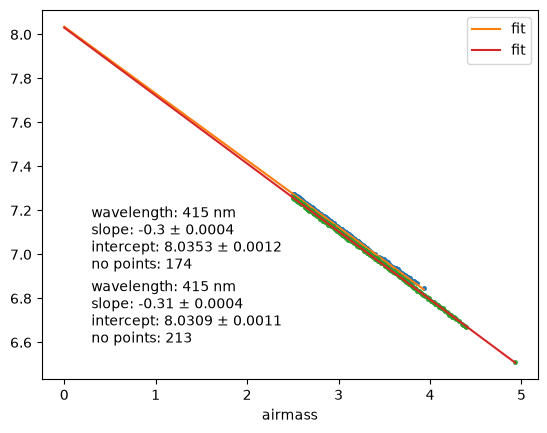

In [101]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

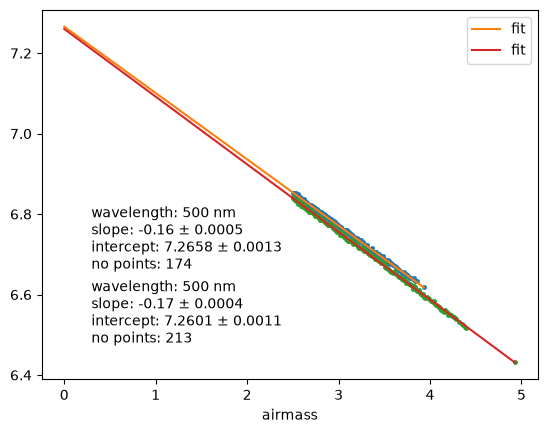

In [102]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

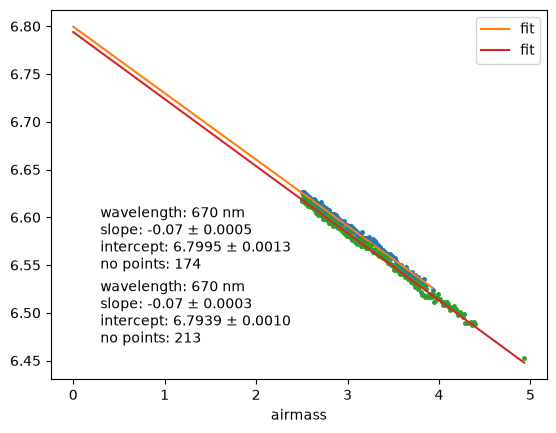

In [103]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

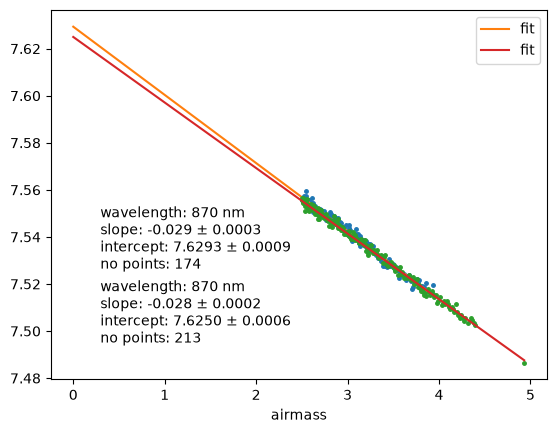

In [104]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

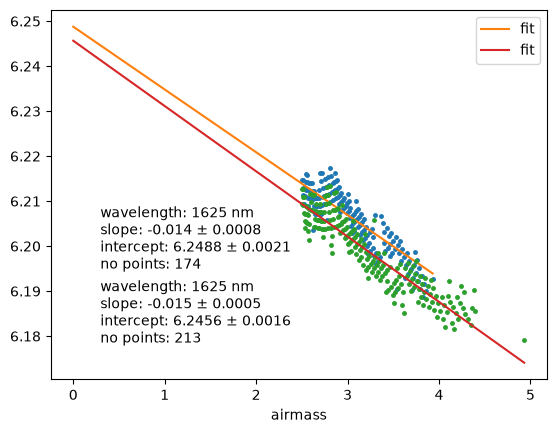

In [105]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [106]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251014.nc')

In [107]:
# p2out.unlink()

In [108]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251014.nc')

In [109]:
# p2out.unlink()

#### pwv

In [110]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0014	 skewscale:2.0055
skewness: -0.0160	 skewscale:2.0640
skewness: -0.0098	 skewscale:2.0392
skewness: -0.0004	 skewscale:2.0016
skewness: -0.0044	 skewscale:2.0177
skewness: -0.1143	 skewscale:2.4573
skewness: -0.1103	 skewscale:2.4410
skewness: -0.1083	 skewscale:2.4330


skewness: -0.1104	 skewscale:2.4416


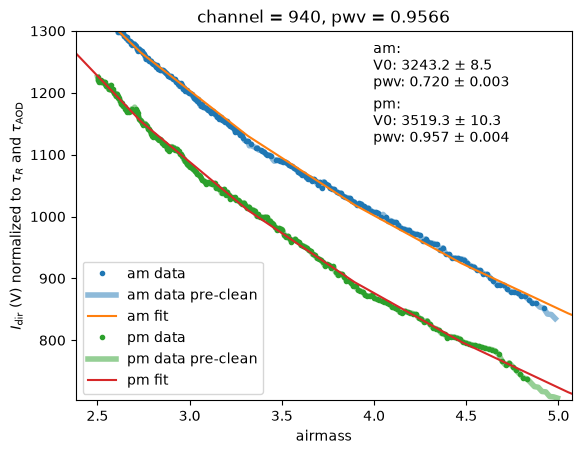

In [111]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1300)
a.legend(loc = 3)

In [112]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251014.nc')

In [113]:
# p2out.unlink()

In [114]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251014.nc')

In [115]:
# p2out.unlink()

### 20251013

In [116]:
%matplotlib inline

In [117]:
date = '1013'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

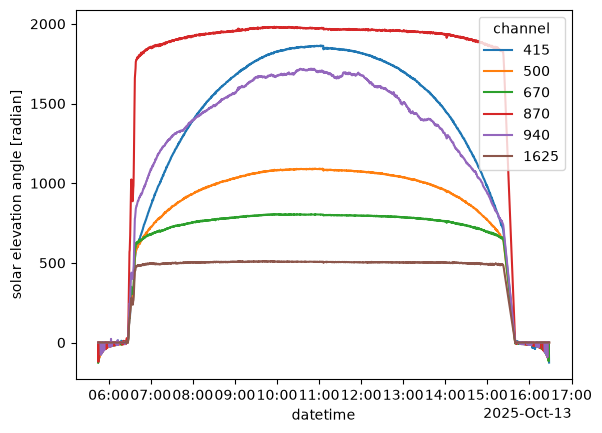

In [118]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [119]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [120]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.1239	 skewscale:2.4956
skewness: 0.1408	 skewscale:2.5630
skewness: 0.1515	 skewscale:2.6060
skewness: 0.1596	 skewscale:2.6383
skewness: 0.1510	 skewscale:2.6041
skewness: 0.1729	 skewscale:2.6917
skewness: 0.1801	 skewscale:2.7205
skewness: 0.1346	 skewscale:2.5384
skewness: 0.0882	 skewscale:2.3527
skewness: 0.1035	 skewscale:2.4139
skewness: 0.0376	 skewscale:2.1505
skewness: 0.0099	 skewscale:2.0398
skewness: -0.0433	 skewscale:2.1732
skewness: -0.0594	 skewscale:2.2376
skewness: 0.1192	 skewscale:2.4770
skewness: 0.1065	 skewscale:2.4258
skewness: 0.0966	 skewscale:2.3863
skewness: 0.0296	 skewscale:2.1183
skewness: -0.0060	 skewscale:2.0239
skewness: -0.0319	 skewscale:2.1278
skewness: -0.0658	 skewscale:2.2632


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

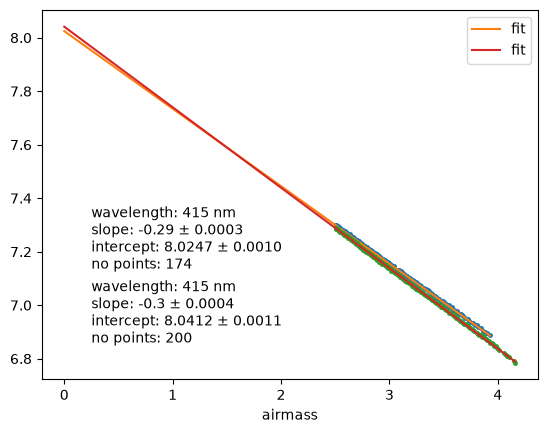

In [121]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

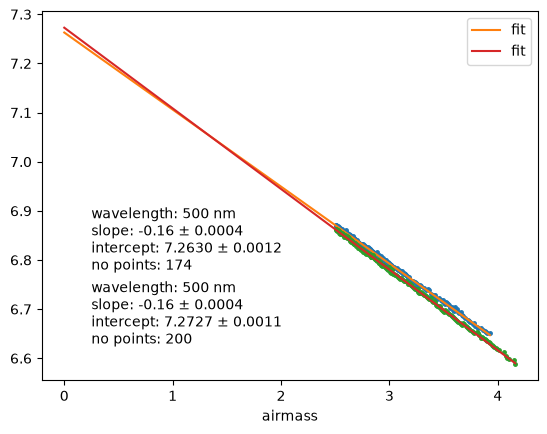

In [122]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

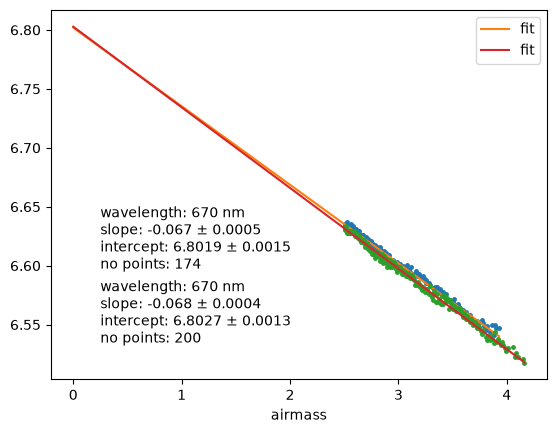

In [123]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

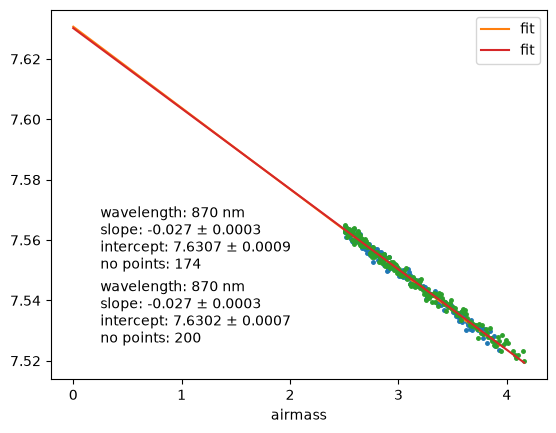

In [124]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

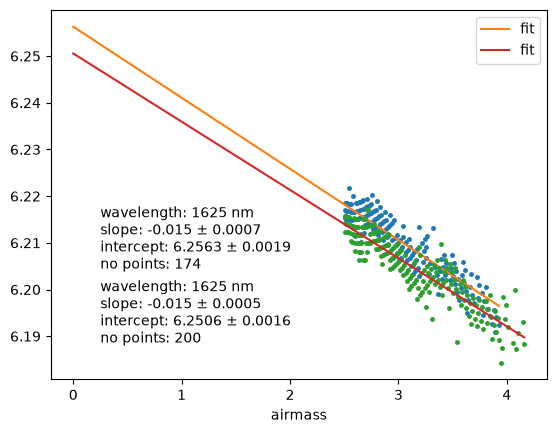

In [125]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [126]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251013.nc')

In [127]:
# p2out.unlink()

In [128]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251013.nc')

In [129]:
# p2out.unlink()

#### pwv

In [130]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: 0.2770	 skewscale:3.1079
skewness: 0.0199	 skewscale:2.0796
skewness: 0.0189	 skewscale:2.0756
skewness: 0.0194	 skewscale:2.0776


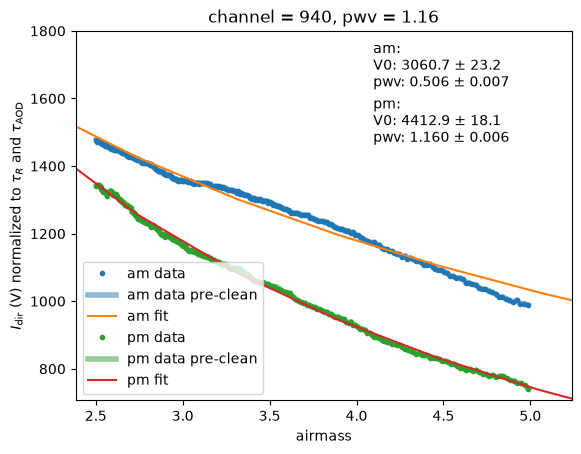

In [132]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1800)
a.legend(loc = 3)

In [133]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251013.nc')

In [134]:
# p2out.unlink()

In [135]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251013.nc')

In [136]:
# p2out.unlink()

### 20251012

In [137]:
%matplotlib inline

In [138]:
date = '1012'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

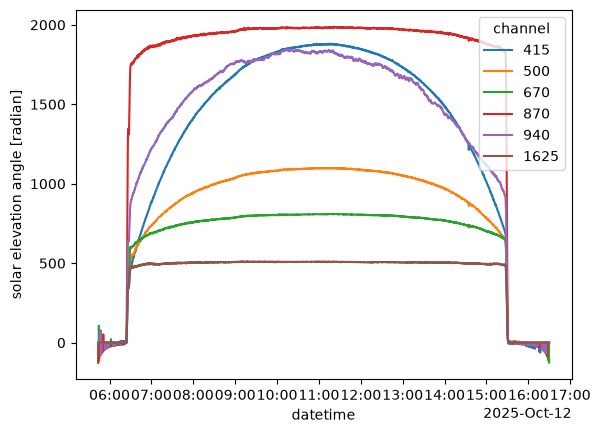

In [139]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [140]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [141]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.1676	 skewscale:2.6704
skewness: 0.1873	 skewscale:2.7490
skewness: 0.1285	 skewscale:2.5141
skewness: 0.0274	 skewscale:2.1095
skewness: -0.0687	 skewscale:2.2746
skewness: -0.0721	 skewscale:2.2884
skewness: -0.0701	 skewscale:2.2806
skewness: 0.2548	 skewscale:3.0193
skewness: 0.2553	 skewscale:3.0212


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

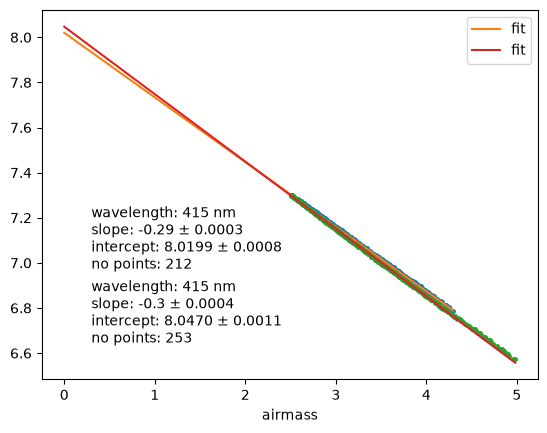

In [142]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

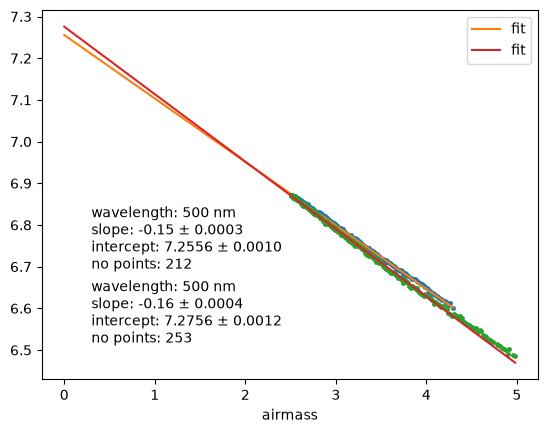

In [143]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

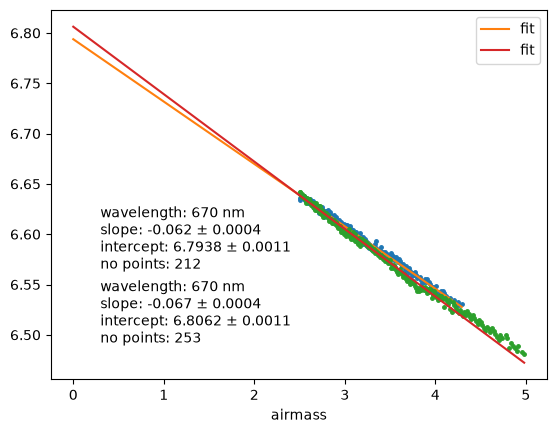

In [144]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

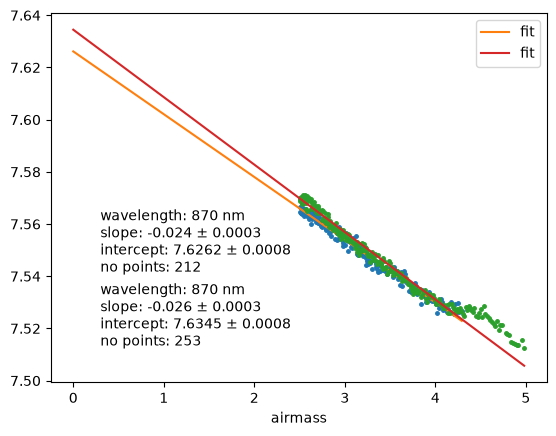

In [145]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

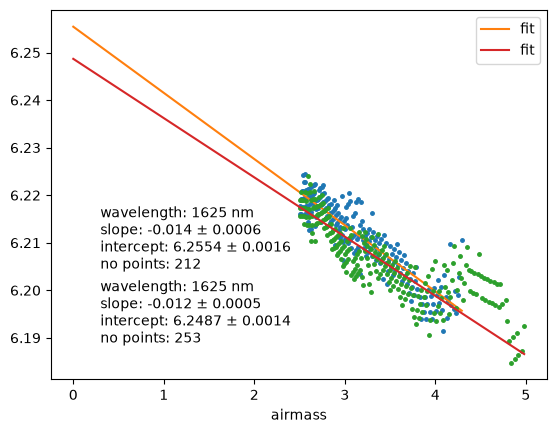

In [146]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [147]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251012.nc')

In [148]:
# p2out.unlink()

In [149]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251012.nc')

In [150]:
# p2out.unlink()

#### pwv

In [151]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0786	 skewscale:2.3144
skewness: -0.0468	 skewscale:2.1873
skewness: -0.0092	 skewscale:2.0369
skewness: 0.0324	 skewscale:2.1297
skewness: 0.0206	 skewscale:2.0825
skewness: -0.0485	 skewscale:2.1942


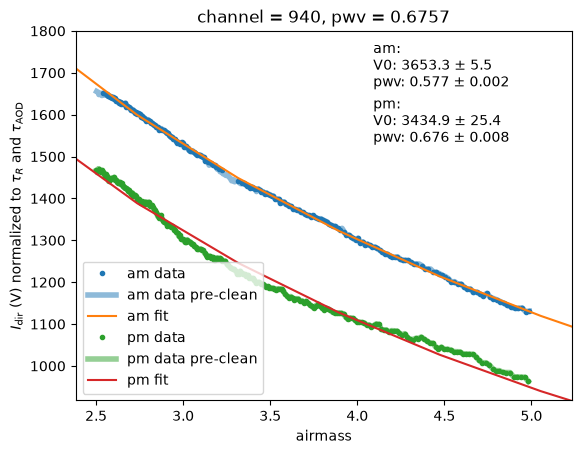

In [153]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1800)
a.legend(loc = 3)

In [154]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251012.nc')

In [155]:
# p2out.unlink()

In [156]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251012.nc')

In [157]:
# p2out.unlink()

### 20251011

In [158]:
%matplotlib inline

In [159]:
date = '1011'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

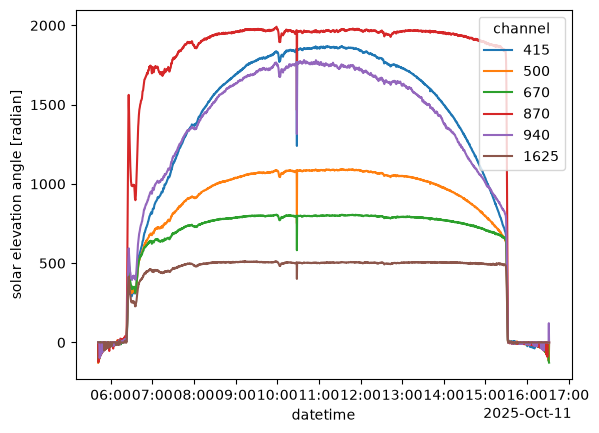

In [160]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [161]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [162]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.0705	 skewscale:2.2821
skewness: 0.1898	 skewscale:2.7592
skewness: 0.1403	 skewscale:2.5613
skewness: 0.1067	 skewscale:2.4266
skewness: 0.0318	 skewscale:2.1271
skewness: 0.0055	 skewscale:2.0221
skewness: -0.0076	 skewscale:2.0303
skewness: -0.0331	 skewscale:2.1325
skewness: -0.0509	 skewscale:2.2036
skewness: -0.0357	 skewscale:2.1428
skewness: -0.0438	 skewscale:2.1750


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

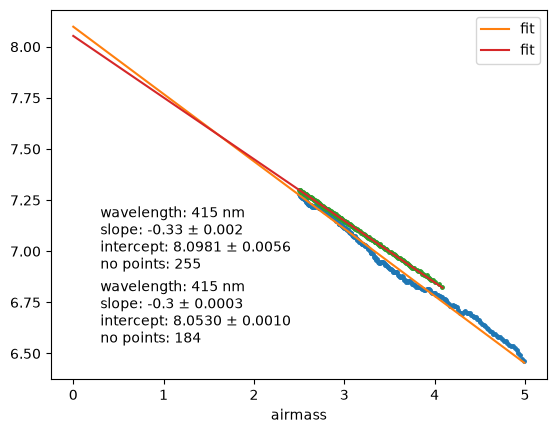

In [163]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

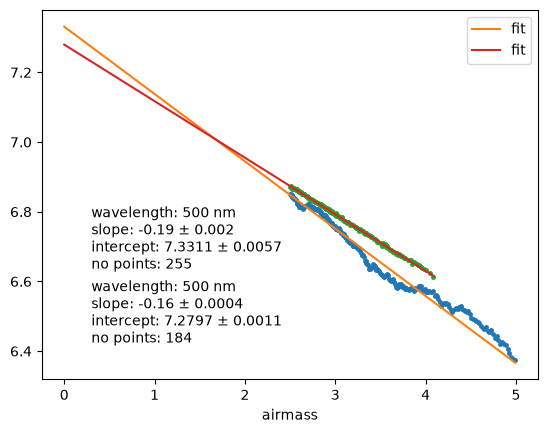

In [164]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

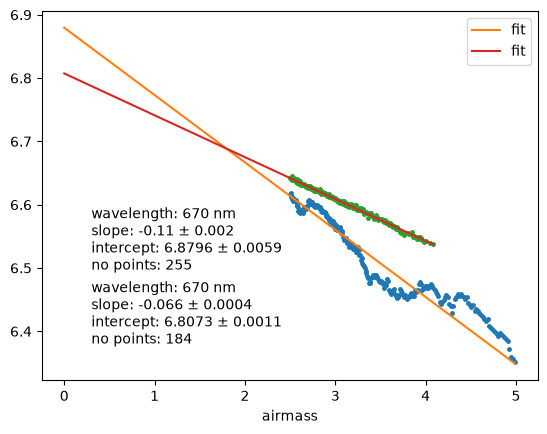

In [165]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

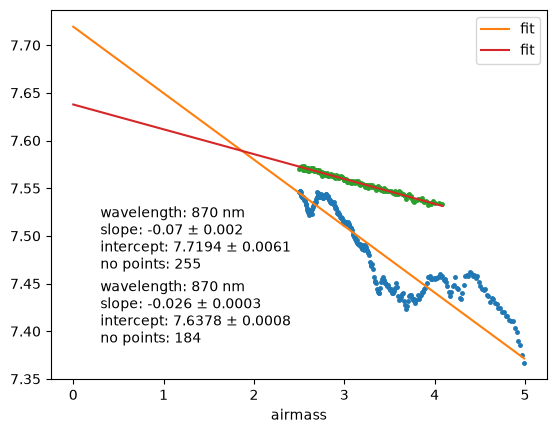

In [166]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

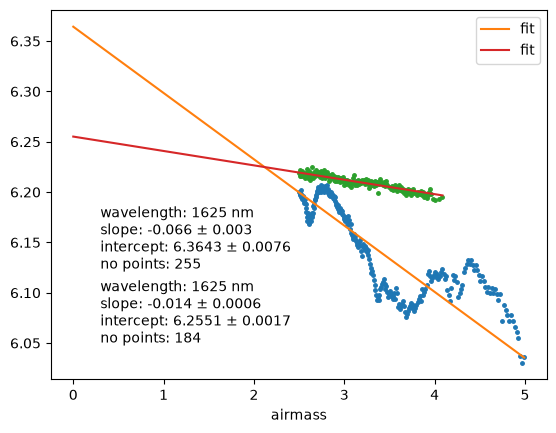

In [167]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [168]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [169]:
# p2out.unlink()

In [170]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251011.nc')

In [171]:
# p2out.unlink()

#### pwv

In [172]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.1693	 skewscale:2.6770
skewness: 0.0512	 skewscale:2.2049


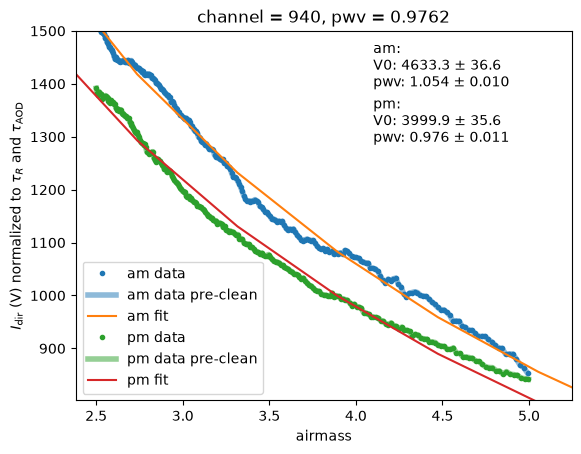

In [173]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [174]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [175]:
# p2out.unlink()

In [176]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/649.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251011.nc')

In [177]:
# p2out.unlink()

### 20251002

In [178]:
data ='1002'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_20251002.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_20251002_preliminary.nc'
# lt = lt_pre_648

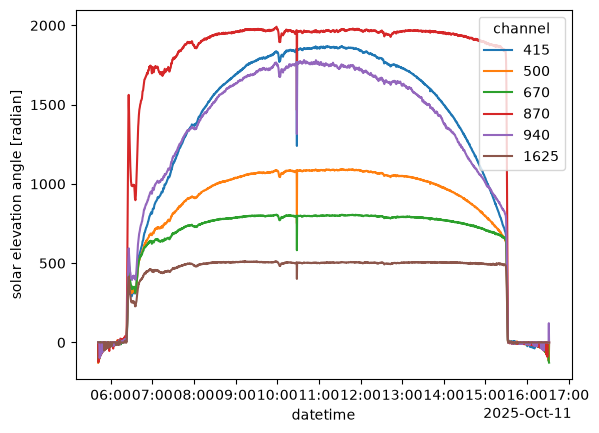

In [179]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [180]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------


ValueError: Ozone data is all none or zero! Try setting it with a constant value.

In [181]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.0705	 skewscale:2.2821
skewness: 0.1898	 skewscale:2.7592
skewness: 0.1403	 skewscale:2.5613
skewness: 0.1067	 skewscale:2.4266
skewness: 0.0318	 skewscale:2.1271
skewness: 0.0055	 skewscale:2.0221
skewness: -0.0076	 skewscale:2.0303
skewness: -0.0331	 skewscale:2.1325
skewness: -0.0509	 skewscale:2.2036
skewness: -0.0357	 skewscale:2.1428
skewness: -0.0438	 skewscale:2.1750


In [ ]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

In [ ]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [ ]:
# p2out.unlink()

In [ ]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

In [ ]:
# p2out.unlink()

#### pwv

In [ ]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


In [ ]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [ ]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [ ]:
# p2out.unlink()

In [ ]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

In [ ]:
# p2out.unlink()

### 20250928

In [182]:
date = '0928'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

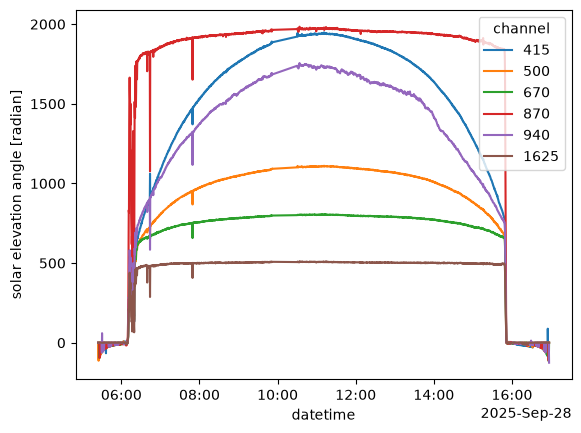

In [183]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [184]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


AssertionError: 

In [ ]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

In [ ]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

In [ ]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [ ]:
# p2out.unlink()

In [ ]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

In [ ]:
# p2out.unlink()

#### pwv

In [ ]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


In [ ]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [ ]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [ ]:
# p2out.unlink()

In [ ]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

In [ ]:
# p2out.unlink()